# DACIS — Notebook 2: Inference, Evaluation & Interpretation

Phase 1 restores the assets produced at the end of Notebook 1 (processed graphs + trained weights).
Phases 2–4 cover evaluation, explainability, topological feature injection, and export — in that
priority order, since Phase 2 and Phase 4a are what move the paper's numbers; Phase 3 is scoped to
a handful of case studies rather than an exhaustive sweep; Phase 4b (JSON/Cytoscape export) is the
lowest priority and only worth doing once 1–4a are solid.

In [1]:
%%capture
!pip install torch-geometric numpy pandas pyarrow networkx matplotlib seaborn scikit-learn --quiet

In [2]:
from __future__ import annotations

import json
import math
import os
import random
import warnings
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.explain import Explainer, GNNExplainer
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, auc, f1_score, confusion_matrix
)

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
warnings.filterwarnings("ignore")


# Ground-truth copy from Notebook 1 — kept identical so paths and behavior match exactly.
@dataclass
class Config:
    ELLIPTIC_DIR: str = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"
    AMLSIM_DIR: str = "/kaggle/input/datasets/anshankul/ibm-amlsim-example-dataset"
    PAYSIM_DIR: str = "/kaggle/input/datasets/ealaxi/paysim1"

    RANDOM_SEED: int = 42
    EPOCHS: int = 100
    LR: float = 0.005
    WEIGHT_DECAY: float = 5e-4
    HIDDEN_DIM: int = 64

cfg = Config()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(cfg.RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.RANDOM_SEED)
np.random.seed(cfg.RANDOM_SEED)
random.seed(cfg.RANDOM_SEED)

NB1_INPUT_DIR = Path("/kaggle/input/datasets/kaushik2005/dacisnotebook2")
PROCESSED_DIR = NB1_INPUT_DIR / "Processed"
EXPORT_DIR = Path(".")/ "exports"
EXPORT_DIR.mkdir(exist_ok=True)

print(f"Hardware initialization complete. Using device: {device}")

Hardware initialization complete. Using device: cuda


In [3]:
# Ground-truth copy of the model architecture from Notebook 1 (cell 4).
# aggr='max' is a confirmed architectural decision — do not change to 'mean'.
class DACISGraphSAGE(nn.Module):
    def __init__(self, in_channels: int, hidden_channels: int, out_channels: int, dropout: float = 0.3):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr='max')
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels, aggr='max')
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.linear = nn.Linear(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        return self.linear(x)

In [4]:
# Ground-truth copy of the metrics + training loop from Notebook 1 (cell 5).
# Needed again here because Phase 4a retrains a fresh model on augmented features.
def compute_metrics(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor, threshold: float = 0.5) -> dict:
    with torch.no_grad():
        mask_idx = mask.nonzero(as_tuple=False).view(-1)
        if mask_idx.numel() == 0:
            return {"auroc": 0.0, "auprc": 0.0, "f1": 0.0, "probs": np.array([]), "labels": np.array([])}

        filtered_logits = logits[mask_idx]
        filtered_labels = labels[mask_idx].cpu().numpy()

        probs = F.softmax(filtered_logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= threshold).astype(int)

        if len(np.unique(filtered_labels)) < 2:
            return {"auroc": 0.5, "auprc": 0.0, "f1": 0.0, "probs": probs, "labels": filtered_labels}

        auroc = roc_auc_score(filtered_labels, probs)
        precision, recall, _ = precision_recall_curve(filtered_labels, probs)
        auprc = auc(recall, precision)
        f1 = f1_score(filtered_labels, preds, zero_division=0)

        return {"auroc": auroc, "auprc": auprc, "f1": f1, "probs": probs, "labels": filtered_labels}


def best_threshold_for_f1(probs: np.ndarray, labels: np.ndarray) -> float:
    if len(np.unique(labels)) < 2:
        return 0.5
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    f1s = 2 * precision * recall / (precision + recall + 1e-12)
    best_idx = np.nanargmax(f1s[:-1])
    return float(thresholds[best_idx])


def train_and_evaluate(dataset_name: str, data, epochs=100, lr=0.005, weight_decay=5e-4, hidden_dim=64) -> None:
    data = data.to(device)

    train_labels = data.y[data.train_mask].cpu().numpy()
    num_neg = np.sum(train_labels == 0)
    num_pos = np.sum(train_labels == 1)
    pos_weight = float(num_neg) / max(num_pos, 1)

    criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, pos_weight * 1.5], dtype=torch.float32).to(device))

    model = DACISGraphSAGE(
        in_channels=data.num_node_features,
        hidden_channels=hidden_dim,
        out_channels=2
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_score = -1.0
    best_weights_path = NB1_INPUT_DIR / f"{dataset_name.lower()}_best_weights.pt"

    print(f"===========================================================")
    print(f" Executing Optimization Pipeline: {dataset_name} ")
    print(f" Calculated Anomaly Loss Scaling Multiplier: {pos_weight:.2f}")
    print(f"===========================================================")

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)

        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_out = model(data.x, data.edge_index)
            val_metrics = compute_metrics(val_out, data.y, data.val_mask)

        current_val_score = val_metrics["auprc"]
        if current_val_score >= best_val_score:
            best_val_score = current_val_score
            torch.save(model.state_dict(), best_weights_path)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val AUROC: {val_metrics['auroc']:.4f} | Val AUPRC: {val_metrics['auprc']:.4f} | Val F1: {val_metrics['f1']:.4f}")

    print(f"\nEvaluating peak validation parameters against test track...")
    model.load_state_dict(torch.load(best_weights_path, weights_only=True))
    model.eval()

    with torch.no_grad():
        val_out = model(data.x, data.edge_index)
        val_final_metrics = compute_metrics(val_out, data.y, data.val_mask)
        best_thresh = best_threshold_for_f1(val_final_metrics["probs"], val_final_metrics["labels"])

        final_out = model(data.x, data.edge_index)
        test_metrics = compute_metrics(final_out, data.y, data.test_mask, threshold=best_thresh)

    print(f"-----------------------------------------------------------")
    print(f" {dataset_name.upper()} FINAL TEST RESULTS")
    print(f"-----------------------------------------------------------")
    print(f"Selected Threshold : {best_thresh:.4f}")
    print(f"AUROC : {test_metrics['auroc']:.4f}")
    print(f"AUPRC : {test_metrics['auprc']:.4f}")
    print(f"F1    : {test_metrics['f1']:.4f}")
    print(f"Saved : {best_weights_path.resolve()}\n")

## Phase 1 — State Restoration
Reloads the processed PyG graphs and best-checkpoint weights exported at the end of Notebook 1. No Pandas/NetworkX preprocessing here — that overhead is entirely bypassed.

In [5]:
DATASETS = ["elliptic", "amlsim", "paysim"]

def load_processed_graph(name: str) -> Data:
    path = PROCESSED_DIR / f"{name}_pyg_data.pt"
    if not path.exists():
        raise FileNotFoundError(f"{path} not found — re-run Notebook 1's export cell first.")
    data_dict = torch.load(path, weights_only=False)
    return Data(**data_dict)

def load_trained_model(name: str, in_channels: int) -> DACISGraphSAGE:
    weights_path = NB1_INPUT_DIR / f"{name}_best_weights.pt"
    if not weights_path.exists():
        raise FileNotFoundError(f"{weights_path} not found — re-run Notebook 1's training cell for {name} first.")
    model = DACISGraphSAGE(in_channels=in_channels, hidden_channels=cfg.HIDDEN_DIM, out_channels=2)
    model.load_state_dict(torch.load(weights_path, map_location=device, weights_only=True))
    model.to(device)
    model.eval()
    return model

assets = {}
for name in DATASETS:
    try:
        data = load_processed_graph(name).to(device)
        model = load_trained_model(name, in_channels=data.num_node_features)
        assets[name] = {"data": data, "model": model}
        print(f"[{name}] restored — nodes={data.num_nodes}, features={data.num_node_features}, edges={data.edge_index.shape[1]}")
    except FileNotFoundError as e:
        print(f"[{name}] SKIPPED — {e}")

print(f"\nRestored {len(assets)}/{len(DATASETS)} dataset(s): {list(assets.keys())}")

[elliptic] restored — nodes=203769, features=165, edges=234355
[amlsim] restored — nodes=1323234, features=2, edges=2646468
[paysim] restored — nodes=1214803, features=2, edges=1000000

Restored 3/3 dataset(s): ['elliptic', 'amlsim', 'paysim']


## Phase 2a — Precision-Recall & ROC Curves
PR curves are the more informative diagnostic here given how imbalanced all three datasets are; ROC is included alongside for completeness.

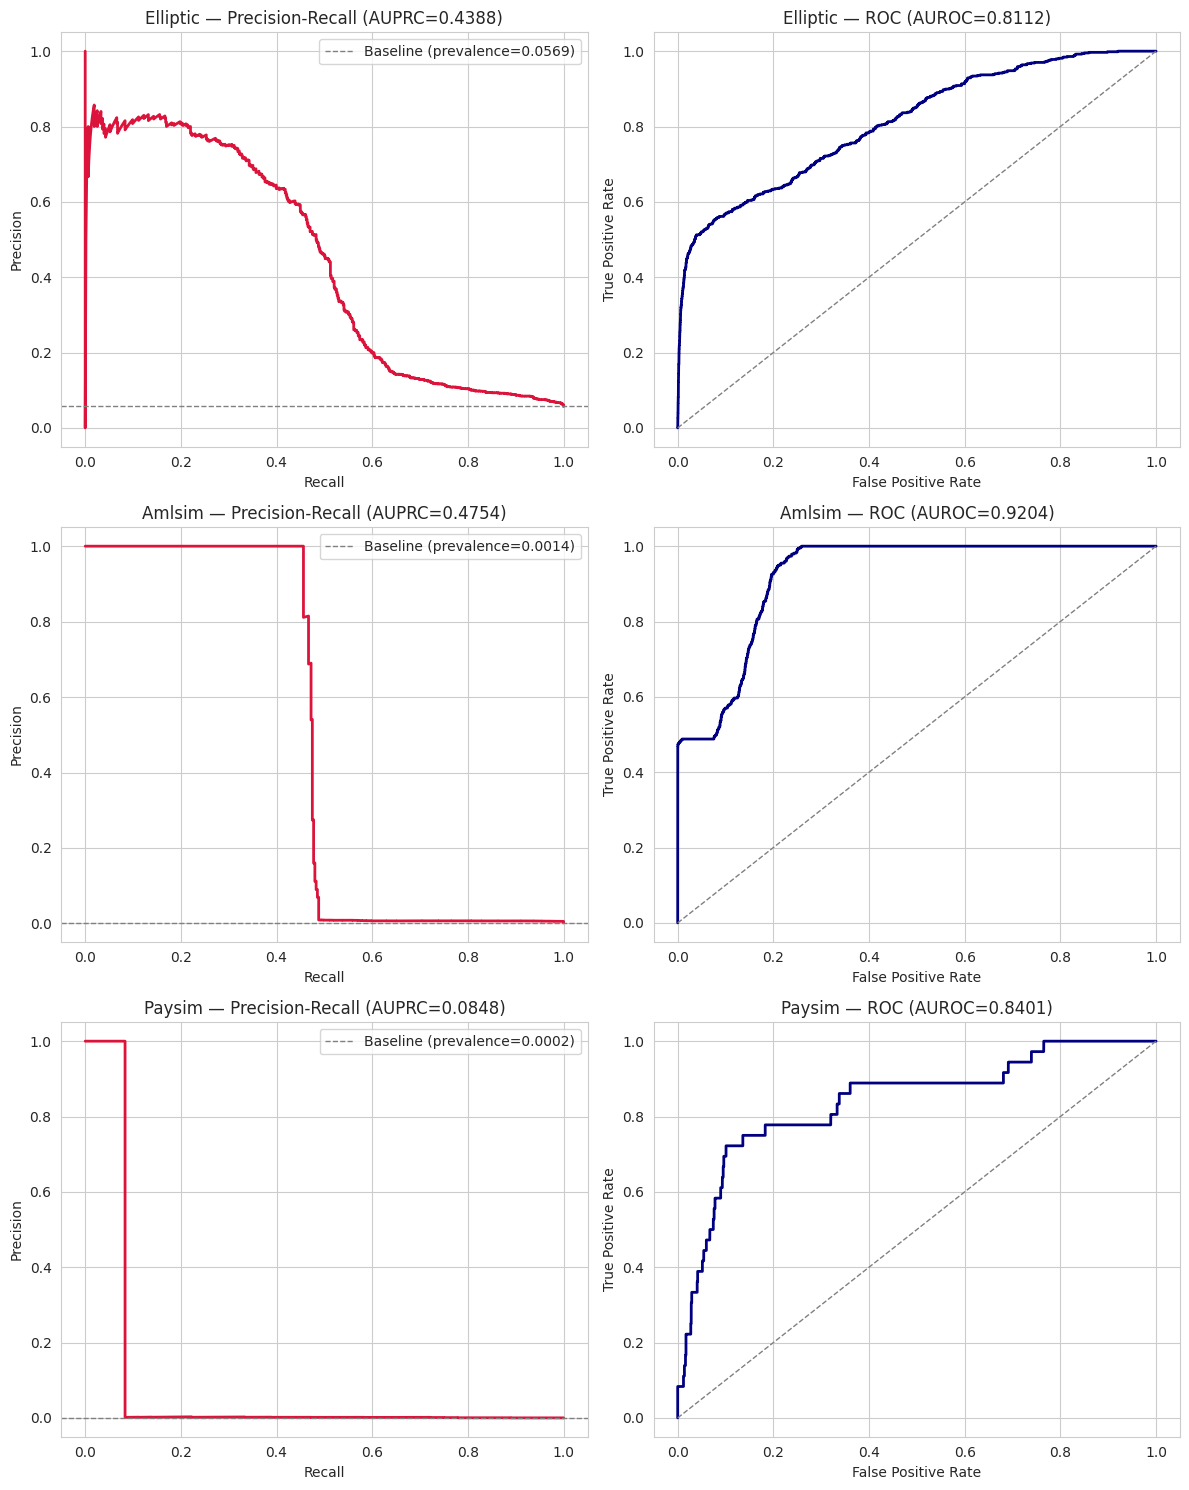

In [6]:
def get_test_probs_labels(name):
    data = assets[name]["data"]
    model = assets[name]["model"]
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    metrics = compute_metrics(out, data.y, data.test_mask)
    return metrics["probs"], metrics["labels"]

fig, axes = plt.subplots(len(assets), 2, figsize=(12, 5 * len(assets)))
if len(assets) == 1:
    axes = axes.reshape(1, 2)

for row, name in enumerate(assets):
    probs, labels = get_test_probs_labels(name)

    precision, recall, _ = precision_recall_curve(labels, probs)
    auprc = auc(recall, precision)
    axes[row, 0].plot(recall, precision, color="crimson", lw=2)
    axes[row, 0].axhline(labels.mean(), color="gray", ls="--", lw=1, label=f"Baseline (prevalence={labels.mean():.4f})")
    axes[row, 0].set_title(f"{name.capitalize()} — Precision-Recall (AUPRC={auprc:.4f})")
    axes[row, 0].set_xlabel("Recall"); axes[row, 0].set_ylabel("Precision")
    axes[row, 0].legend(loc="upper right")

    fpr, tpr, _ = roc_curve(labels, probs)
    roc_score = roc_auc_score(labels, probs)
    axes[row, 1].plot(fpr, tpr, color="navy", lw=2)
    axes[row, 1].plot([0, 1], [0, 1], color="gray", ls="--", lw=1)
    axes[row, 1].set_title(f"{name.capitalize()} — ROC (AUROC={roc_score:.4f})")
    axes[row, 1].set_xlabel("False Positive Rate"); axes[row, 1].set_ylabel("True Positive Rate")

plt.tight_layout()
plt.show()

## Phase 2b/2c — Threshold Tuning & Confusion Matrices
Tunes the decision threshold on val (maximizing F1 for the illicit class), then applies it to test. Confusion matrices are normalized so the false-positive (legit blocked) vs false-negative (fraud missed) tradeoff is directly readable.

[elliptic] False Positive Rate (legit blocked): 0.0668 | False Negative Rate (fraud missed): 0.4607
[amlsim] False Positive Rate (legit blocked): 0.0000 | False Negative Rate (fraud missed): 0.5438
[paysim] False Positive Rate (legit blocked): 0.0000 | False Negative Rate (fraud missed): 0.9167


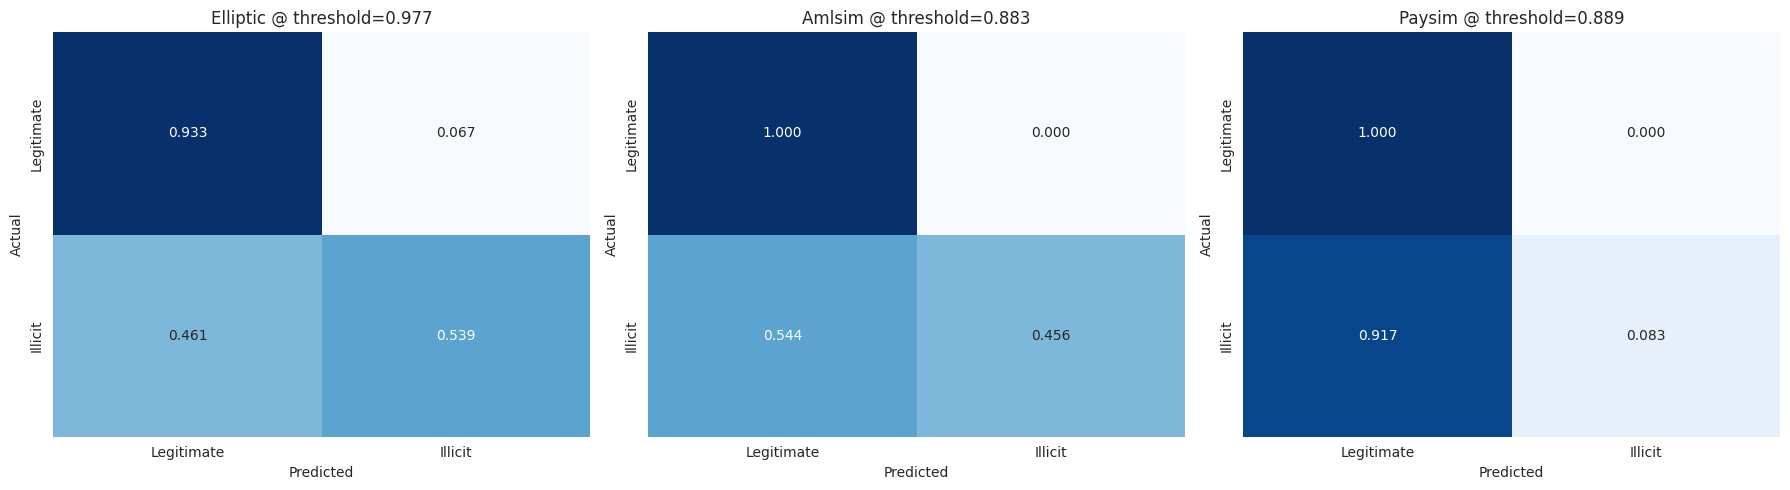

,dataset,threshold,auroc,auprc,f1
0,elliptic,0.976736,0.811192,0.438778,0.407363
1,amlsim,0.883330,0.920400,0.475371,0.626594
2,paysim,0.889331,0.840093,0.084756,0.150000


In [7]:
def evaluate_with_tuned_threshold(name):
    data = assets[name]["data"]
    model = assets[name]["model"]
    with torch.no_grad():
        out = model(data.x, data.edge_index)
    val_metrics = compute_metrics(out, data.y, data.val_mask)
    best_thresh = best_threshold_for_f1(val_metrics["probs"], val_metrics["labels"])
    test_metrics = compute_metrics(out, data.y, data.test_mask, threshold=best_thresh)
    return best_thresh, test_metrics

threshold_results = {}
fig, axes = plt.subplots(1, len(assets), figsize=(6 * len(assets), 5))
if len(assets) == 1:
    axes = [axes]

for ax, name in zip(axes, assets):
    best_thresh, test_metrics = evaluate_with_tuned_threshold(name)
    threshold_results[name] = {"threshold": best_thresh, **test_metrics}

    preds = (test_metrics["probs"] >= best_thresh).astype(int)
    cm = confusion_matrix(test_metrics["labels"], preds, normalize="true")

    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", cbar=False,
                xticklabels=["Legitimate", "Illicit"], yticklabels=["Legitimate", "Illicit"], ax=ax)
    ax.set_title(f"{name.capitalize()} @ threshold={best_thresh:.3f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

    if cm.shape == (2, 2):
        fp_rate, fn_rate = cm[0, 1], cm[1, 0]
        print(f"[{name}] False Positive Rate (legit blocked): {fp_rate:.4f} | False Negative Rate (fraud missed): {fn_rate:.4f}")

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame([
    {"dataset": name, "threshold": r["threshold"], "auroc": r["auroc"], "auprc": r["auprc"], "f1": r["f1"]}
    for name, r in threshold_results.items()
])
summary_df

## Phase 3 — Graph Explainability (scoped)

Running GNNExplainer over every test node isn't worth the runtime against the Aug 21 deadline — it's
per-node optimization, not a batched forward pass. This scopes it to the top-3 most confident
true-positive fraud nodes per dataset: enough for a feature-importance discussion and a "laundering
ring" figure in the paper, without burning days of compute for marginal additional insight.


--- ELLIPTIC | node 189916 ---
Top feature contributions:
           feat_1 : 0.7308
           feat_0 : 0.0000
           feat_2 : 0.0000
           feat_3 : 0.0000
           feat_4 : 0.0000
Top contributing transaction edges (src -> dst : importance), 1 edge(s) retained:
  1 -> 0 : 0.1344


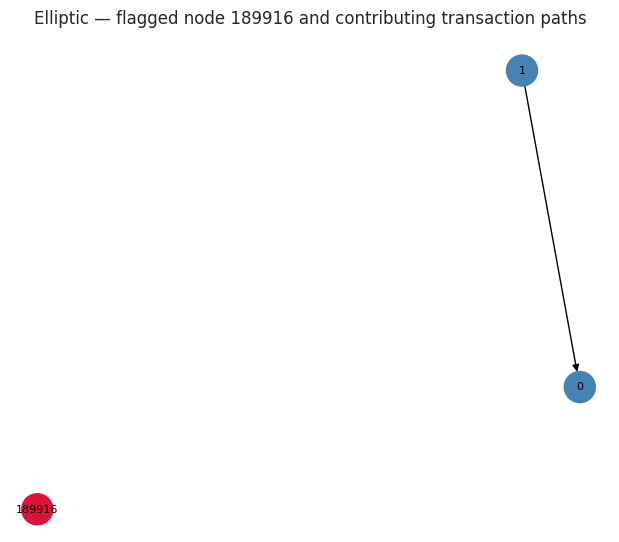


--- ELLIPTIC | node 157681 ---
Top feature contributions:
           feat_1 : 0.7285
         feat_141 : 0.7121
         feat_147 : 0.6862
         feat_144 : 0.6674
           feat_5 : 0.2788
Top contributing transaction edges (src -> dst : importance), 0 edge(s) retained:

--- ELLIPTIC | node 158303 ---
Top feature contributions:
         feat_141 : 0.7835
         feat_144 : 0.4582
           feat_0 : 0.0000
           feat_1 : 0.0000
           feat_2 : 0.0000
Top contributing transaction edges (src -> dst : importance), 2 edge(s) retained:
  0 -> 1 : 0.8813
  2 -> 0 : 0.1200

--- AMLSIM | node 1178990 ---
Top feature contributions:
      feat_amount : 0.6631
        feat_type : 0.0000
Top contributing transaction edges (src -> dst : importance), 2 edge(s) retained:
  0 -> 1 : 0.8338
  2 -> 0 : 0.8263


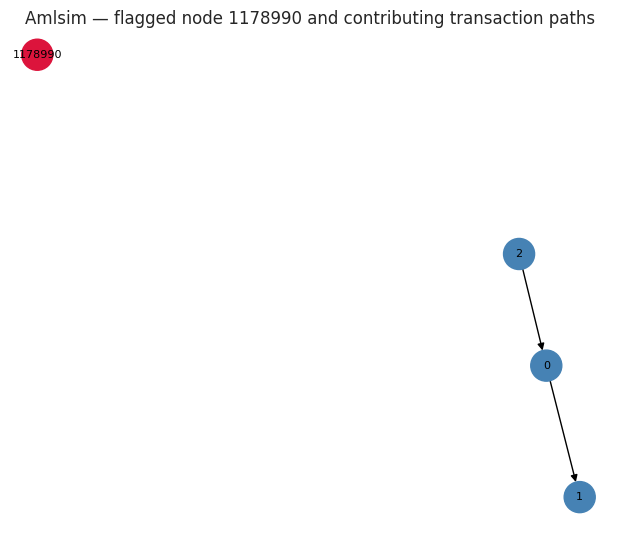


--- AMLSIM | node 1247089 ---
Top feature contributions:
      feat_amount : 0.6403
        feat_type : 0.0000
Top contributing transaction edges (src -> dst : importance), 2 edge(s) retained:
  0 -> 1 : 0.8144
  2 -> 0 : 0.8083

--- AMLSIM | node 1114537 ---
Top feature contributions:
      feat_amount : 0.7078
        feat_type : 0.0000
Top contributing transaction edges (src -> dst : importance), 2 edge(s) retained:
  0 -> 1 : 0.8502
  2 -> 0 : 0.8486

--- PAYSIM | node 481251 ---
Top feature contributions:
      feat_amount : 0.6993
        feat_type : 0.4820


RuntimeError: indices should be either on cpu or on the same device as the indexed tensor (cpu)

In [8]:
def explain_node(name, node_idx, top_k_edges=8):
    data = assets[name]["data"]
    model = assets[name]["model"]

    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=150),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(mode='multiclass_classification', task_level='node', return_type='raw'),
        threshold_config=dict(threshold_type='topk', value=top_k_edges),
    )
    return explainer(data.x, data.edge_index, index=node_idx)


def summarize_explanation(name, node_idx, explanation, feature_names=None):
    node_importance = explanation.node_mask[node_idx].detach().cpu().numpy()
    if feature_names is None:
        feature_names = [f"feat_{i}" for i in range(len(node_importance))]
    feat_ranking = sorted(zip(feature_names, node_importance), key=lambda t: -t[1])[:5]

    print(f"\n--- {name.upper()} | node {node_idx} ---")
    print("Top feature contributions:")
    for feat, score in feat_ranking:
        print(f"  {feat:>15s} : {score:.4f}")

    pruned = explanation.get_explanation_subgraph()
    print(f"Top contributing transaction edges (src -> dst : importance), {pruned.edge_index.shape[1]} edge(s) retained:")
    for e in range(pruned.edge_index.shape[1]):
        src, dst = pruned.edge_index[0, e].item(), pruned.edge_index[1, e].item()
        print(f"  {src} -> {dst} : {pruned.edge_mask[e].item():.4f}")
    return pruned


def plot_explanation_subgraph(name, node_idx, pruned):
    G = nx.DiGraph()
    G.add_edges_from(pruned.edge_index.t().tolist())
    if node_idx not in G.nodes():
        G.add_node(node_idx)
    pos = nx.spring_layout(G, seed=cfg.RANDOM_SEED)
    node_colors = ["crimson" if n == node_idx else "steelblue" for n in G.nodes()]
    plt.figure(figsize=(6, 5))
    nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=500, font_size=8, arrows=True)
    plt.title(f"{name.capitalize()} — flagged node {node_idx} and contributing transaction paths")
    plt.show()


FEATURE_NAMES = {
    "elliptic": None,  # feat_0..feat_165: no public semantic names beyond the original paper's grouping
    "amlsim": ["feat_amount", "feat_type"],
    "paysim": ["feat_amount", "feat_type"],
}

case_studies = {}
for name in assets:
    data = assets[name]["data"]
    model = assets[name]["model"]
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        probs = F.softmax(out, dim=1)[:, 1]

    tp_mask = data.test_mask & (data.y == 1) & (probs >= 0.5)
    tp_indices = tp_mask.nonzero(as_tuple=False).view(-1)
    if tp_indices.numel() == 0:
        print(f"[{name}] no confident true-positive nodes in test set — skipping explainability case study.")
        continue

    top_conf_idx = probs[tp_indices].topk(min(3, tp_indices.numel())).indices
    selected_nodes = tp_indices[top_conf_idx].tolist()
    case_studies[name] = selected_nodes

    for i, node_idx in enumerate(selected_nodes):
        explanation = explain_node(name, node_idx)
        pruned = summarize_explanation(name, node_idx, explanation, feature_names=FEATURE_NAMES[name])
        if i == 0:
            plot_explanation_subgraph(name, node_idx, pruned)

## Phase 4a — Topological Feature Injection

Directly addresses the feature-poverty ceiling on AMLSim/PaySim (2 raw features vs Elliptic's 166
curated ones) flagged earlier. Skipped for Elliptic since it's already feature-rich. Retrains a
fresh model per dataset since the input dimension changes — checkpoints are saved separately
(`{name}_topo_best_weights.pt`) so the Phase-1 baselines aren't overwritten.